# Construindo o pipeline do zero: do CSV ao DuckDB

Este notebook é uma aula guiada: você vai construir, célula por célula, as mesmas peças que já existem em `scripts/extract_csv.py`, `scripts/extract_weather.py` e `scripts/transform.sql`, só que aqui dá pra parar em cada passo e entender o "porquê" antes de ver a versão final do script.

**Importante:** este notebook grava num banco **separado** (`warehouse/aula_pipeline.duckdb`), não no `workshop.duckdb` que alimenta o Metabase: pode rodar, quebrar e rodar de novo sem medo de estragar a dashboard da aula.

Roteiro:
1. Ler um CSV
2. O problema: duas fontes, dois esquemas
3. Renomear colunas
4. Transformar isso numa função reutilizável
5. Escrever o resultado no DuckDB
6. Fazer uma requisição numa API externa
7. Repetir a requisição para todas as cidades
8. Juntar tudo num mini pipeline, o mesmo desenho do `run_pipeline.py`
9. Staging em SQL puro: reconciliar e limpar as vendas
10. Staging em SQL puro: clima
11. Mart: responder a pergunta de negócio
12. Stretch: os outros marts
13. Resumo final
14. Agora é sua vez: perguntas de negócio

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import requests

RAW_CSV = Path("../data/raw/vendas_lojas.csv")
INCOMING_CSV = Path("../data/incoming/vendas_lojas_recentes.csv")

# Banco de sandbox só desta aula, separado do warehouse/workshop.duckdb
# que o Metabase usa, pra podermos experimentar sem medo de estragar nada
DB_PATH = Path("../warehouse/aula_pipeline.duckdb")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

## 1. Lendo um CSV

`pandas.read_csv` já lê pelo **nome** da coluna (o header), não pela posição. Isso importa porque, como vamos ver já na próxima seção, as duas fontes de venda da GeloDados têm colunas em nomes e ordens diferentes: ler por posição quebraria silenciosamente.

In [ ]:
# dtype=str: deixamos tudo como texto por enquanto, igual ao CSV cru.
# A tipagem (converter pra número, data etc.) é trabalho da staging, mais
# pra frente, não da leitura em si.
historico = pd.read_csv(RAW_CSV, dtype=str)
historico.head()

In [9]:
print(f"{len(historico)} linhas")
print(f"colunas: {list(historico.columns)}")


4400 linhas
colunas: ['data_venda', 'loja_id', 'cidade', 'cliente_id', 'nome_cliente', 'idade_cliente', 'genero_cliente', 'produto', 'sabor', 'unidades_vendidas', 'preco_unitario', 'receita_brl', 'forma_pagamento']


In [10]:
historico.head().T

,0,1,2,3,4
data_venda,2026-06-16,2026-06-01,2026-06-19,25/08/2026,2026-08-22
loja_id,LJ03,LJ03,LJ02,LJ05,LJ05
cidade,Curitiba,Curitiba,Rio de Janeiro,Porto Alegre,Porto Alegre
cliente_id,CLI00039,CLI00071,CLI00049,CLI00030,CLI00148
nome_cliente,Eduarda Ferreira,Thiago Martins,Henrique Souza,Bruno Santos,Otavio Oliveira
idade_cliente,64.0,50.0,20.0,25.0,63.0
genero_cliente,F,F,F,M,M
produto,Sorvete Pote,Picole,Sorvete Pote,Picole,Picole
sabor,Chocolate,Morango,Chocolate,Limao,Limao
unidades_vendidas,2,1,2,2,3


In [54]:
historico.genero_cliente.value_counts(dropna=False)

genero_cliente
F        2252
M        2005
NaN        73
Outro      70
Name: count, dtype: int64

## 2. O problema: duas fontes, dois esquemas

O time comercial trocou de sistema de ponto de venda na metade da janela de dados. O arquivo `vendas_lojas_recentes.csv` tem **a mesma informação**, só que com colunas renomeadas e em outra ordem.


In [12]:
recentes = pd.read_csv(INCOMING_CSV, dtype=str)
recentes.head()

,id_cliente,nm_cliente,dt_venda,id_loja,uf_cidade,categoria_produto,sabor_item,qtd_vendida,vl_unitario,vl_total,tipo_pagamento,idade,genero
0,CLI00027,Sabrina Lima,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,8.96,35.84,pix,32,M
1,CLI00021,Sabrina Souza,2026-08-28,LJ01,Sao Paulo,Milkshake,Ovomaltine,1,13.83,13.83,cartao,59,F
2,CLI00087,Rafael Silva,2026-08-28,LJ01,Sao Paulo,Picole,Limao,3,6.1,18.3,dinheiro,58,M
3,CLI00047,Gabriela Martins,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,7.86,31.44,cartao,35,F
4,CLI00133,Joao Lima,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,6.99,27.96,pix,58,M


In [13]:
# As colunas não batem: juntar os dois DataFrames direto (pd.concat) ia
# criar um Frankenstein de colunas, a maioria cheia de NaN
set(historico.columns) ^ set(recentes.columns)

{'categoria_produto',
 'cidade',
 'cliente_id',
 'data_venda',
 'dt_venda',
 'forma_pagamento',
 'genero',
 'genero_cliente',
 'id_cliente',
 'id_loja',
 'idade',
 'idade_cliente',
 'loja_id',
 'nm_cliente',
 'nome_cliente',
 'preco_unitario',
 'produto',
 'qtd_vendida',
 'receita_brl',
 'sabor',
 'sabor_item',
 'tipo_pagamento',
 'uf_cidade',
 'unidades_vendidas',
 'vl_total',
 'vl_unitario'}

## 3. Renomeando colunas

A solução: um dicionário explícito de `nome_na_fonte -> nome_canônico`, igual ao que `scripts/transform.sql` faz em SQL. Aqui fazemos a mesma reconciliação, só que em pandas.


In [26]:
mapeamento_recentes = {
    "dt_venda": "data_venda",
    "id_loja": "loja_id",
    "uf_cidade": "cidade",
    "id_cliente": "cliente_id",
    "nm_cliente": "nome_cliente",
    "idade": "idade_cliente",
    "genero": "genero_cliente",
    "categoria_produto": "produto",
    "sabor_item": "sabor",
    "qtd_vendida": "unidades_vendidas",
    "vl_unitario": "preco_unitario",
    "vl_total": "receita_brl",
    "tipo_pagamento": "forma_pagamento",
}

recentes_renomeado = recentes.rename(columns=mapeamento_recentes)
recentes_renomeado.head()


,cliente_id,nome_cliente,data_venda,loja_id,cidade,produto,sabor,unidades_vendidas,preco_unitario,receita_brl,forma_pagamento,idade_cliente,genero_cliente
0,CLI00027,Sabrina Lima,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,8.96,35.84,pix,32,M
1,CLI00021,Sabrina Souza,2026-08-28,LJ01,Sao Paulo,Milkshake,Ovomaltine,1,13.83,13.83,cartao,59,F
2,CLI00087,Rafael Silva,2026-08-28,LJ01,Sao Paulo,Picole,Limao,3,6.1,18.3,dinheiro,58,M
3,CLI00047,Gabriela Martins,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,7.86,31.44,cartao,35,F
4,CLI00133,Joao Lima,2026-08-28,LJ01,Sao Paulo,Agua de Coco,Coco,4,6.99,27.96,pix,58,M


In [18]:
set(historico.columns) == set(recentes_renomeado.columns)

True

In [19]:
vendas = pd.concat([historico, recentes_renomeado], ignore_index=True)
print(f"{len(vendas)} linhas no total, agora com um único esquema de colunas")

4660 linhas no total, agora com um único esquema de colunas


## 4. Transformando isso numa função

Reparou que "ler o CSV" e "renomear se precisar" é uma receita que vamos repetir para qualquer fonte nova que aparecer? Isso é sinal de que vale a pena virar uma função.


In [42]:
def carregar_vendas(caminho_csv, mapeamento=None):
    df = pd.read_csv(caminho_csv, dtype=str)
    if mapeamento:
        df = df.rename(columns=mapeamento)
    return df


historico_v2 = carregar_vendas(RAW_CSV)
recentes_v2 = carregar_vendas(INCOMING_CSV, mapeamento=mapeamento_recentes)

vendas = pd.concat([historico_v2, recentes_v2], ignore_index=True)
vendas.head()

,data_venda,loja_id,cidade,cliente_id,nome_cliente,idade_cliente,genero_cliente,produto,sabor,unidades_vendidas,preco_unitario,receita_brl,forma_pagamento
0,2026-06-16,LJ03,Curitiba,CLI00039,Eduarda Ferreira,64,F,Sorvete Pote,Chocolate,2,20.59,41.18,dinheiro
1,2026-06-01,LJ03,Curitiba,CLI00071,Thiago Martins,50,F,Picole,Morango,1,4.98,4.98,cartao
2,2026-06-19,LJ02,Rio de Janeiro,CLI00049,Henrique Souza,20,F,Sorvete Pote,Chocolate,2,18.36,36.72,dinheiro
3,25/08/2026,LJ05,Porto Alegre,CLI00030,Bruno Santos,25,M,Picole,Limao,2,5.63,11.26,cartao
4,2026-08-22,LJ05,Porto Alegre,CLI00148,Otavio Oliveira,63,M,Picole,Limao,3,5.78,17.34,pix


### Pausa pra praticar

Quantas linhas de `historico_v2` têm `idade_cliente` vazia? (Lembre: estamos lendo com `dtype=str`, então "vazia" aqui pode ser string vazia `""` ou `NaN`, dependendo de como o pandas leu a célula do CSV.)

In [51]:
# seu código aqui
print(historico_v2.idade_cliente.value_counts(dropna=False))

idade_cliente
32     192
33     168
43     148
59     145
63     139
26     138
72     135
35     135
61     128
49     127
28     123
29     121
20     120
36     116
58     114
39     113
65     109
70     102
18     100
17     100
22      94
41      86
19      85
53      85
57      82
21      80
64      79
25      78
68      77
47      77
45      72
30      65
71      64
48      64
NaN     60
67      60
50      59
54      54
23      53
51      53
69      37
56      35
27      34
24      33
60      32
52      30
42      30
62      30
66      28
31      25
46      24
34      22
16      20
37      20
Name: count, dtype: int64


## 5. Escrevendo no DuckDB

DuckDB não tem um "insira este DataFrame direto numa tabela nova": o jeito mais simples é **registrar** o DataFrame como uma view temporária (`con.register`) e usar `CREATE TABLE ... AS SELECT * FROM` para materializar.

Também usamos **schemas** (`raw`, `staging`, `mart`) pra deixar claro em que estágio de limpeza cada tabela está. Aqui só vamos até `raw`.

In [56]:
con = duckdb.connect(str(DB_PATH))
con.execute("CREATE SCHEMA IF NOT EXISTS raw")

con.register("_tmp_vendas", vendas)
con.execute("CREATE OR REPLACE TABLE raw.vendas AS SELECT * FROM _tmp_vendas")
con.unregister("_tmp_vendas")

con.execute("SELECT COUNT(*) AS total FROM raw.vendas").df()


,total
0,4660


In [57]:
con.execute("SELECT COUNT(*) AS total FROM raw.vendas WHERE idade_cliente IS NULL").df()

,total
0,60


Essa sequência (`register` → `CREATE OR REPLACE TABLE` → `unregister`) também vale a pena virar função: vamos usá-la de novo já na próxima seção.

In [58]:
def salvar_no_duckdb(con, df, tabela):
    con.register("_tmp", df)
    con.execute(f"CREATE OR REPLACE TABLE {tabela} AS SELECT * FROM _tmp")
    con.unregister("_tmp")
    print(f"{len(df)} linhas -> {tabela}")


# repare: salvamos "recentes" (schema original), não "recentes_v2"
# (já renomeado). O raw deve espelhar a fonte fielmente; quem reconcilia
# o nome das colunas é a camada de staging, em SQL, mais abaixo.
salvar_no_duckdb(con, historico_v2, "raw.vendas_historico")
salvar_no_duckdb(con, recentes, "raw.vendas_recentes")

4400 linhas -> raw.vendas_historico
260 linhas -> raw.vendas_recentes


### Pausa pra praticar

E se você rodar `salvar_no_duckdb(con, historico_v2, "raw.vendas_historico")` de novo, uma segunda vez: isso duplica as linhas de `raw.vendas_historico` (fica com o dobro) ou não? Teste antes de adivinhar: compare `SELECT COUNT(*) FROM raw.vendas_historico` antes e depois de chamar a função de novo.

In [ ]:
# seu código aqui

Resposta: não duplica. `CREATE OR REPLACE TABLE` descarta a tabela antiga por completo e recria com o resultado do `SELECT` mais recente, a cada chamada. É bem diferente de um `INSERT INTO`, que SIM empilharia os dados de novo a cada execução.

## 6. Fazendo uma requisição numa API

O clima não existe nos sistemas internos da GeloDados: precisa vir de uma **API pública**, a [Open-Meteo](https://open-meteo.com/). `requests.get` com os parâmetros certos (coordenadas + janela de datas) devolve um JSON com a série diária.

In [61]:
resp = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": -23.5505,
        "longitude": -46.6333,
        "start_date": "2026-06-01",
        "end_date": "2026-06-10",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "America/Sao_Paulo",
    },
    timeout=10,
)
resp.raise_for_status()
dados = resp.json()
dados["daily"]


{'time': ['2026-06-01',
  '2026-06-02',
  '2026-06-03',
  '2026-06-04',
  '2026-06-05',
  '2026-06-06',
  '2026-06-07',
  '2026-06-08',
  '2026-06-09',
  '2026-06-10'],
 'temperature_2m_max': [20.2,
  20.1,
  22.0,
  22.4,
  21.1,
  22.5,
  22.8,
  23.7,
  23.6,
  24.5],
 'temperature_2m_min': [13.1,
  11.3,
  14.1,
  14.0,
  11.5,
  11.5,
  10.3,
  9.2,
  11.4,
  12.0],
 'precipitation_sum': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.8]}

O JSON vem "achatado" em listas paralelas (uma lista de datas, uma de temperaturas máximas, etc.). É só remontar isso num DataFrame.

In [62]:
clima_sp = pd.DataFrame({
    "cidade": "Sao Paulo",
    "data": dados["daily"]["time"],
    "temp_max_c": dados["daily"]["temperature_2m_max"],
    "temp_min_c": dados["daily"]["temperature_2m_min"],
    "precipitacao_mm": dados["daily"]["precipitation_sum"],
})
clima_sp


,cidade,data,temp_max_c,temp_min_c,precipitacao_mm
0,Sao Paulo,2026-06-01,20.2,13.1,0.0
1,Sao Paulo,2026-06-02,20.1,11.3,0.0
2,Sao Paulo,2026-06-03,22.0,14.1,0.0
3,Sao Paulo,2026-06-04,22.4,14.0,0.0
4,Sao Paulo,2026-06-05,21.1,11.5,0.0
5,Sao Paulo,2026-06-06,22.5,11.5,0.0
6,Sao Paulo,2026-06-07,22.8,10.3,0.0
7,Sao Paulo,2026-06-08,23.7,9.2,0.0
8,Sao Paulo,2026-06-09,23.6,11.4,0.0
9,Sao Paulo,2026-06-10,24.5,12.0,3.8


In [63]:
# mesma função de sempre, não importa se o dado veio de CSV ou de API
salvar_no_duckdb(con, clima_sp, "raw.clima_sp")

10 linhas -> raw.clima_sp


## 7. Repetindo para todas as cidades

A GeloDados tem 5 lojas em 5 cidades, e a janela de vendas vai de 2026-06-01 a 2026-09-01. O teste acima foi só São Paulo, em 10 dias. Pra responder a pergunta de negócio de verdade (o clima influencia as vendas?), precisamos do clima de TODAS as cidades, na janela TODA.

Mesma lógica de sempre: vira função, chama em loop.

In [64]:
COORDENADAS = {
    "Sao Paulo": (-23.5505, -46.6333),
    "Rio de Janeiro": (-22.9068, -43.1729),
    "Curitiba": (-25.4284, -49.2733),
    "Fortaleza": (-3.7172, -38.5433),
    "Porto Alegre": (-30.0346, -51.2177),
}


def buscar_clima(cidade, lat, lon):
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": lat,
            "longitude": lon,
            "start_date": "2026-06-01",
            "end_date": "2026-09-01",
            "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
            "timezone": "America/Sao_Paulo",
        },
        timeout=10,
    )
    resp.raise_for_status()
    daily = resp.json()["daily"]
    return pd.DataFrame({
        "cidade": cidade,
        "data": daily["time"],
        "temp_max_c": daily["temperature_2m_max"],
        "temp_min_c": daily["temperature_2m_min"],
        "precipitacao_mm": daily["precipitation_sum"],
    })


clima = pd.concat(
    [buscar_clima(cidade, lat, lon) for cidade, (lat, lon) in COORDENADAS.items()],
    ignore_index=True,
)
salvar_no_duckdb(con, clima, "raw.clima")

465 linhas -> raw.clima


O script de verdade, `scripts/extract_weather.py`, também geocodifica cada cidade (converte o nome em lat/long via outra API) e tem fallback pra um cache local se a internet cair no meio da aula. Aqui simplificamos usando coordenadas fixas direto.

## 8. Juntando tudo: o mesmo desenho do `run_pipeline.py`

Com as peças prontas (`carregar_vendas`, `salvar_no_duckdb`), "o pipeline" é só chamar essas funções na ordem certa. Dá uma olhada em `scripts/run_pipeline.py` depois: é exatamente essa ideia, só chamando os scripts de verdade em vez de funções dentro de um notebook.

In [66]:
def pipeline_de_vendas():
    historico = carregar_vendas(RAW_CSV)
    recentes = carregar_vendas(INCOMING_CSV)
    salvar_no_duckdb(con, historico, "raw.vendas_historico")
    salvar_no_duckdb(con, recentes, "raw.vendas_recentes")

pipeline_de_vendas()

4400 linhas -> raw.vendas_historico
260 linhas -> raw.vendas_recentes


In [67]:
con.execute("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema = 'raw'
    ORDER BY table_name
""").df()


,table_schema,table_name
0,raw,clima
1,raw,clima_sp
2,raw,vendas
3,raw,vendas_historico
4,raw,vendas_recentes


## 9. Staging em SQL puro: limpando as vendas

A reconciliação de nomes (seção 3, em pandas) já está em `raw.vendas`: `historico` e `recentes` já com o mesmo esquema de colunas. Não precisamos refazer isso em SQL.

O que falta: `raw.vendas` ainda tem linhas duplicadas (lembra que fizemos `pd.concat` sem `drop_duplicates`?) e tudo ainda está como texto. Vamos construir `stg_vendas` com um `SELECT` sobre `raw.vendas`, coluna por coluna, junto com a turma.

**Requisitos de `stg_vendas` (a partir de `raw.vendas`):**

- remover linhas duplicadas exatas (`SELECT DISTINCT`)
- `data_venda`: texto em dois formatos (`2026-06-01` ou `01/06/2026`); converter os dois pra `DATE`
- `nome_cliente`, `genero_cliente`: trocar string vazia por `NULL` (`NULLIF`)
- `idade_cliente`: trocar string vazia por `NULL` e converter pra `INTEGER` (cuidado: `CAST` direto numa string vazia dá erro; use `TRY_CAST` como proteção extra)
- `unidades_vendidas`: converter pra `INTEGER`
- `preco_unitario`, `receita_brl`: converter pra `DOUBLE`
- nova coluna `unidades_suspeitas`: `TRUE` quando `unidades_vendidas > 50` (não apaga a linha, só sinaliza)
- `loja_id`, `cidade`, `cliente_id`, `produto`, `sabor`, `forma_pagamento`: já estão ok como texto, sem transformação

In [ ]:
con.execute("""
    CREATE OR REPLACE TABLE stg_vendas AS
    SELECT * FROM raw.vendas
    -- complete aqui: DISTINCT, tratamento de data_venda, idade_cliente,
    -- genero_cliente, nome_cliente, tipos numéricos e unidades_suspeitas
""")

con.execute("SELECT * FROM stg_vendas LIMIT 5").df()

### Pausa pra praticar

Quantas linhas de `stg_vendas` têm `genero_cliente` nulo? Escreva a consulta SQL (dica: `WHERE genero_cliente IS NULL`).

In [ ]:
# seu código aqui

## 10. Staging em SQL puro: clima

Mesma ideia da seção anterior, só que o clima já vem bem mais limpo (sem duplicata, sem texto fora do formato esperado): só precisa tipar.

**Requisitos de `stg_clima` (a partir de `raw.clima`):**

- `cidade`: já ok como texto, sem transformação
- `data`: converter pra `DATE`
- `temp_max_c`, `temp_min_c`, `precipitacao_mm`: converter pra `DOUBLE`

In [ ]:
con.execute("""
    CREATE OR REPLACE TABLE stg_clima AS
    SELECT * FROM raw.clima
    -- complete aqui: CAST pra DATE e pros números
""")

con.execute("SELECT * FROM stg_clima LIMIT 5").df()

## 11. Mart: a pergunta de negócio

Com `stg_vendas` e `stg_clima` prontos, a pergunta central do case (vendemos mais quando está mais quente?) é só um `JOIN` mais uma agregação. `stg_vendas` está no grão de transação; `stg_clima` está no grão de dia/cidade: agregamos as vendas pro grão dia/loja antes de juntar.

**Requisitos de `mart_vendas_clima`:**

- `LEFT JOIN` entre `stg_vendas` e `stg_clima` por `cidade` e por data (`v.data_venda = c.data`); `LEFT` pra não perder vendas em dias sem clima
- agregar no grão dia + loja: `qtd_transacoes` (`COUNT(*)`), `unidades_vendidas` (`SUM`), `receita_total_brl` (`SUM`)
- trazer `temp_max_c`, `temp_min_c`, `precipitacao_mm` do dia
- nova coluna `faixa_temperatura`: `'< 20C'` se `temp_max_c < 20`, `'20-28C'` se `< 28`, senão `'> 28C'`
- agrupar por `data_venda`, `loja_id`, `cidade` e pelas 3 colunas de clima

In [ ]:
con.execute("""
    CREATE OR REPLACE TABLE mart_vendas_clima AS
    SELECT * FROM stg_vendas
    -- complete aqui: JOIN com stg_clima, agregações, faixa_temperatura, GROUP BY
""")

mart = con.execute("SELECT * FROM mart_vendas_clima").df()
mart.head()

O gráfico abaixo só faz sentido depois que `mart_vendas_clima` estiver completo (com o `JOIN` e a agregação).

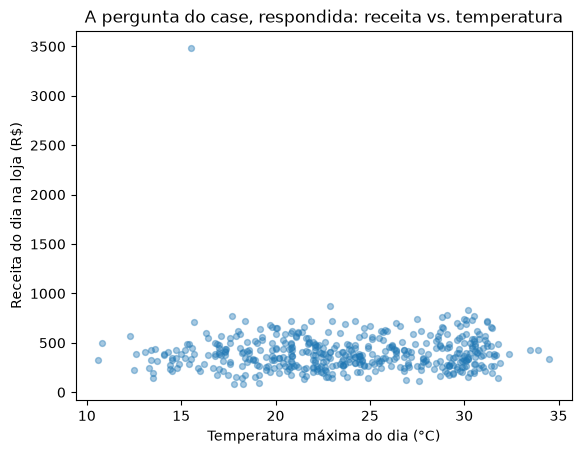

In [72]:
fig, ax = plt.subplots()
ax.scatter(mart["temp_max_c"], mart["receita_total_brl"], alpha=0.4, s=18)
ax.set_xlabel("Temperatura máxima do dia (°C)")
ax.set_ylabel("Receita do dia na loja (R$)")
ax.set_title("A pergunta do case, respondida: receita vs. temperatura")
plt.show()

### Pausa pra praticar

Qual cidade teve a maior receita total nos dias de faixa `'> 28C'`? Escreva a consulta em `mart_vendas_clima` (dica: `WHERE faixa_temperatura = '> 28C'`, agrupando por `cidade`).

In [ ]:
# seu código aqui

## 12. Stretch: os outros marts

`scripts/transform.sql` também cria `mart_sabor_temperatura` e `mart_clientes`, com a mesma receita de `JOIN` mais agregação.

**Requisitos de `mart_sabor_temperatura`:**

- mesmo `LEFT JOIN` de `stg_vendas` com `stg_clima` (por `cidade` e data)
- agrupar por `produto`, `sabor` e `faixa_temperatura` (mesma lógica de faixa da seção 11)
- somar `unidades_vendidas` e `receita_brl`

In [ ]:
con.execute("""
    CREATE OR REPLACE TABLE mart_sabor_temperatura AS
    SELECT * FROM stg_vendas
    -- complete aqui: JOIN, faixa_temperatura, GROUP BY produto/sabor/faixa
""")

con.execute("SELECT * FROM mart_sabor_temperatura ORDER BY unidades_vendidas DESC LIMIT 5").df()

**Requisitos de `mart_clientes`:**

- descobrir a `loja_favorita` de cada cliente: a loja onde ele mais comprou (dica: `COUNT(*)` por cliente+loja, depois `ROW_NUMBER()` particionado por cliente, ordenado pela contagem decrescente, pegando a linha 1)
- agregar por cliente: `qtd_compras` (`COUNT`), `receita_total_brl` (`SUM`), `ticket_medio_brl` (`ROUND(AVG(...), 2)`)

In [ ]:
con.execute("""
    CREATE OR REPLACE TABLE mart_clientes AS
    SELECT * FROM stg_vendas
    -- complete aqui: loja_favorita (ROW_NUMBER), agregações por cliente
""")

con.execute("SELECT * FROM mart_clientes ORDER BY receita_total_brl DESC LIMIT 5").df()

## 13. Resumo final

Fechando com o mesmo resumo que `run_pipeline.py` imprime no final: contagem de linhas de cada tabela do banco.

In [ ]:
tabelas = con.execute("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
    ORDER BY table_schema, table_name
""").fetchall()

for schema, tabela in tabelas:
    nome_completo = f"{schema}.{tabela}" if schema != "main" else tabela
    count = con.execute(f"SELECT COUNT(*) FROM {nome_completo}").fetchone()[0]
    print(f"{nome_completo:30s} {count:>6d} linhas")

## 14. Agora é sua vez: perguntas de negócio

Os marts estão prontos. Use `mart_vendas_clima`, `mart_sabor_temperatura` e `mart_clientes` (em SQL ou pandas, como preferir) para responder:

**1.** A loja com a maior receita total (`mart_vendas_clima`) é a mesma loja com o maior ticket médio por transação (`receita_total_brl / qtd_transacoes`)? Calcule os dois rankings e compare.

In [ ]:
con.execute("""
    SELECT * FROM mart_vendas_clima
""").df()

**2.** Considerando todas as faixas de temperatura juntas, qual é o sabor mais vendido em unidades (`mart_sabor_temperatura`)?

In [ ]:
con.execute("""
    SELECT * FROM mart_sabor_temperatura
""").df()

**3.** Quantos clientes (`mart_clientes`) têm `ticket_medio_brl` acima de R$ 50? Qual `loja_favorita` é mais comum entre eles?

In [ ]:
con.execute("""
    SELECT * FROM mart_clientes
""").df()

**4.** Combinando o que você viu em `mart_vendas_clima` e `mart_sabor_temperatura`: dias mais quentes vendem proporcionalmente mais Picolé do que Sorvete Pote? Escreva uma consulta que sustente sua resposta.

In [ ]:
con.execute("""
    SELECT * FROM mart_vendas_clima
    -- pode precisar também de mart_sabor_temperatura
""").df()

## Para ir além

- Compare o que você fez aqui com os scripts de verdade: `scripts/extract_csv.py`, `scripts/extract_weather.py` e `scripts/transform.sql`. A lógica é a mesma; os scripts têm mais tratamento de erro (cache offline de clima, fallback de coordenadas via geocoding) e são a versão que o `python scripts/run_pipeline.py` roda de verdade.
- **Exercício:** troque os limites da faixa de temperatura (`< 20C`, `20-28C`, `> 28C`) por faixas diferentes (ex.: 4 faixas em vez de 3) e veja como o gráfico da seção 11 muda.
- **Exercício:** `mart_sabor_temperatura` responde "qual sabor vende mais por temperatura". Escreva uma consulta parecida que responda "qual sabor vende mais por loja" (sem considerar temperatura).
- Quando estiver confiante, rode o pipeline de verdade: `python scripts/run_pipeline.py`. Ele usa o banco oficial `workshop.duckdb` (não o banco de sandbox que criamos aqui).

In [ ]:
con.close()